In [361]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [362]:
REGION = 'ExtNord'
YEAR = 2025

In [363]:
grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', encoding=enc)
grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [364]:
# grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_grouped.csv', encoding=enc)
# grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [365]:
grouped_file.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,25.72,32.47,19.06,17.01,37.26,0.0055,0.1713,0.1713,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,29.81,20.62,64.45,350.45,48.0,16.0,32.0,27.67,28.83,33.83,26.67,598.0,236.0,0.0,129.17,568.0,1.0,29.0,237.0
1,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,26.29,33.35,19.34,16.96,38.11,0.0018,0.0562,0.0562,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,30.62,20.75,62.88,356.32,49.0,16.0,33.0,28.67,29.67,34.50,27.17,564.0,220.0,0.0,125.39,521.0,0.0,43.0,220.0
2,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,25.81,32.30,19.41,16.74,36.85,0.0132,0.4100,0.4100,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,29.44,19.12,59.77,358.01,47.0,15.0,32.0,27.50,28.33,33.50,26.33,590.0,226.0,0.0,129.68,562.0,1.0,27.0,419.0
3,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,25.21,31.54,18.97,16.28,36.19,0.0020,0.0633,0.0633,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,29.50,19.00,63.33,328.42,46.0,16.0,30.0,27.67,28.67,33.33,26.50,614.0,230.0,0.0,127.07,576.0,0.0,38.0,230.0
4,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,26.04,32.71,19.47,16.63,37.35,0.0079,0.2462,0.2462,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,29.81,20.62,62.50,329.43,48.0,15.0,33.0,28.17,29.00,33.50,26.67,613.0,233.0,0.0,126.49,575.0,0.0,38.0,233.0


In [366]:
grouped_file.shape

(2536, 75)

In [367]:
grouped_file_previous.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,27.12,36.12,18.12,14.87,39.70,0.0,0.0,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,29.25,20.33,56.48,355.16,50.0,14.0,36.0,26.67,30.83,34.33,26.50,2007.0,641.0,0.0,139.92,1522.0,0.0,31.0,0.0
1,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,27.63,36.88,18.38,15.08,41.01,0.0,0.0,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,30.21,20.92,59.76,353.85,50.0,15.0,35.0,27.50,31.17,35.33,27.50,2126.0,691.0,0.0,139.58,1609.0,0.0,28.0,1609.0
2,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,27.10,35.55,18.65,15.74,39.24,0.0,0.0,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,29.42,20.83,57.87,363.59,49.0,13.0,36.0,27.17,26.33,34.67,26.33,2132.0,684.0,0.0,139.55,1626.0,0.0,33.0,0.0
3,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,26.63,34.88,18.37,14.86,38.66,0.0,0.0,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,29.00,20.00,57.14,344.44,49.0,14.0,35.0,27.00,30.17,34.17,26.00,2132.0,673.0,0.0,141.63,1634.0,0.0,35.0,0.0
4,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,27.47,36.49,18.46,15.50,40.42,0.0,0.0,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,29.62,20.92,56.53,387.37,51.0,14.0,37.0,26.67,31.00,35.33,26.67,2157.0,690.0,0.0,139.21,1627.0,0.0,32.0,1627.0


In [368]:
grouped_file_previous.shape

(3804, 75)

In [369]:
grouped_file['dt_placement'] = pd.to_datetime(grouped_file['dt_placement'], errors='coerce').dt.to_period('M')
grouped_file_previous['dt_placement'] = pd.to_datetime(grouped_file_previous['dt_placement'], errors='coerce').dt.to_period('M')

In [370]:
grouped_file

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,25.72,32.47,19.06,17.01,37.26,0.0055,0.1713,0.1713,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,29.81,20.62,64.45,350.45,48.0,16.0,32.0,27.67,28.83,33.83,26.67,598.0,236.0,0.0,129.17,568.0,1.0,29.0,237.0
1,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,26.29,33.35,19.34,16.96,38.11,0.0018,0.0562,0.0562,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,30.62,20.75,62.88,356.32,49.0,16.0,33.0,28.67,29.67,34.50,27.17,564.0,220.0,0.0,125.39,521.0,0.0,43.0,220.0
2,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,25.81,32.30,19.41,16.74,36.85,0.0132,0.4100,0.4100,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,29.44,19.12,59.77,358.01,47.0,15.0,32.0,27.50,28.33,33.50,26.33,590.0,226.0,0.0,129.68,562.0,1.0,27.0,419.0
3,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,25.21,31.54,18.97,16.28,36.19,0.0020,0.0633,0.0633,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,29.50,19.00,63.33,328.42,46.0,16.0,30.0,27.67,28.67,33.33,26.50,614.0,230.0,0.0,127.07,576.0,0.0,38.0,230.0
4,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,26.04,32.71,19.47,16.63,37.35,0.0079,0.2462,0.2462,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,29.81,20.62,62.50,329.43,48.0,15.0,33.0,28.17,29.00,33.50,26.67,613.0,233.0,0.0,126.49,575.0,0.0,38.0,233.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2531,2025-08,2025,8,2024,-0.866,-0.500,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,0.605969,0.227675,-0.356192,-0.227675,0.595610,0.223195,-0.355947,-0.223195,0.027736,0.023677,0.023228,0.023677,23.93,26.58,21.29,21.12,29.10,9.0854,281.6467,281.6467,108691.34,1322.49,4.33,172.99,759.46,179.21,0.0,62.92,2224.04,1215.46,3.21,70.29,46.80,2.81,0.0,93.52,31,36.0,30,12,12,3,5,8,28.25,21.00,67.74,298.81,47.0,16.0,31.0,26.50,27.50,31.67,25.50,810.0,281.0,3.0,117.38,733.0,34.0,49.0,309.0
2532,2025-08,2025,8,2024,-0.866,-0.500,extreme nord,mayo

In [371]:
weather_acc = grouped_file[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()
weather_acc_previous = grouped_file_previous[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()

weather_df = pd.concat([weather_acc_previous, weather_acc], ignore_index=True)
weather_df.rename(columns={'dt_placement': 'dt_weather_acc'}, inplace=True)

In [372]:
weather_df

,dt_weather_acc,GID0,GID1,GID2,GID3,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,extreme nord,diamare,bogo,balaza,14.87,39.70,0.0000
1,2024-01,extreme nord,diamare,bogo,balda,15.08,41.01,0.0000
2,2024-01,extreme nord,diamare,bogo,bogo,15.74,39.24,0.0000
3,2024-01,extreme nord,diamare,bogo,borai,14.86,38.66,0.0000
4,2024-01,extreme nord,diamare,bogo,guinggley,15.50,40.42,0.0000
...,...,...,...,...,...,...,...,...
6335,2025-08,extreme nord,mayo-tsanaga,roua,midre,21.12,29.10,281.6467
6336,2025-08,extreme nord,mayo-tsanaga,roua,ndimche,20.84,30.01,276.2933
6337,2025-08,extreme nord,mayo-tsanaga,roua,roua,20.87,30.57,282.8100
6338,2025-08,extreme nord,mayo-tsanaga,roua,soulede,20.21,29.14,285.7180


In [373]:
biovars_temp = grouped_file_previous[['year', 'GID0', 'GID1', 'GID2', 'GID3'] + [col for col in grouped_file_previous.columns if 'bio' in col] ].copy()
biovars_temp.rename(columns={'year': 'year_biovars'}, inplace=True)

In [374]:
biovars_df = (
    biovars_temp
    .groupby(['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'])
    .mean(numeric_only=True)
    .reset_index()
    .round(2)
)

In [375]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024,extreme nord,diamare,bogo,balaza,29.25,20.33,56.48,355.16,50.0,14.0,36.0,26.67,30.83,34.33,26.50,2007.0,641.0,0.0,139.92,1522.0,0.0,31.0,0.0
1,2024,extreme nord,diamare,bogo,balda,30.21,20.92,59.76,353.85,50.0,15.0,35.0,27.50,31.17,35.33,27.50,2126.0,691.0,0.0,139.58,1609.0,0.0,28.0,1609.0
2,2024,extreme nord,diamare,bogo,bogo,29.42,20.83,57.87,363.59,49.0,13.0,36.0,27.17,26.33,34.67,26.33,2132.0,684.0,0.0,139.55,1626.0,0.0,33.0,0.0
3,2024,extreme nord,diamare,bogo,borai,29.00,20.00,57.14,344.44,49.0,14.0,35.0,27.00,30.17,34.17,26.00,2132.0,673.0,0.0,141.63,1634.0,0.0,35.0,0.0
4,2024,extreme nord,diamare,bogo,guinggley,29.62,20.92,56.53,387.37,51.0,14.0,37.0,26.67,31.00,35.33,26.67,2157.0,690.0,0.0,139.21,1627.0,0.0,32.0,1627.0


In [376]:
biovars_df.shape

(317, 24)

In [377]:
df_current = grouped_file.drop(columns=[col for col in grouped_file.columns if 'bio' in col] + ['monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc', 'rainfall_acc']).copy()

In [378]:
df_current.shape

(2536, 52)

In [379]:
df_current['year_biovars'] = df_current['year']-1
df_current['dt_weather_acc'] = df_current['dt_placement']-1

In [380]:
df_current.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc
0,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,25.72,32.47,19.06,0.0055,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,2024,2024-12
1,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,26.29,33.35,19.34,0.0018,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,2024,2024-12
2,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,25.81,32.30,19.41,0.0132,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,2024,2024-12
3,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,25.21,31.54,18.97,0.0020,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,2024,2024-12
4,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,26.04,32.71,19.47,0.0079,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,2024,2024-12


In [381]:
df_current.shape

(2536, 54)

In [382]:
dataset = pd.merge(df_current, biovars_df, on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [383]:
dataset.shape

(2536, 73)

In [384]:
dataset = pd.merge(dataset, weather_df, on=['dt_weather_acc', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [385]:
dataset.shape

(2536, 76)

In [386]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,25.72,32.47,19.06,0.0055,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,2024,2024-12,29.25,20.33,56.48,355.16,50.0,14.0,36.0,26.67,30.83,34.33,26.50,2007.0,641.0,0.0,139.92,1522.0,0.0,31.0,0.0,15.39,37.66,0.1100
1,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,26.29,33.35,19.34,0.0018,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,2024,2024-12,30.21,20.92,59.76,353.85,50.0,15.0,35.0,27.50,31.17,35.33,27.50,2126.0,691.0,0.0,139.58,1609.0,0.0,28.0,1609.0,15.87,38.99,0.4733
2,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,25.81,32.30,19.41,0.0132,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,2024,2024-12,29.42,20.83,57.87,363.59,49.0,13.0,36.0,27.17,26.33,34.67,26.33,2132.0,684.0,0.0,139.55,1626.0,0.0,33.0,0.0,16.24,37.34,0.0000
3,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,25.21,31.54,18.97,0.0020,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,2024,2024-12,29.00,20.00,57.14,344.44,49.0,14.0,35.0,27.00,30.17,34.17,26.00,2132.0,673.0,0.0,141.63,1634.0,0.0,35.0,0.0,15.76,36.32,0.0000
4,2025-01,2025,1,2024,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,26.04,32.71,19.47,0.0079,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,2024,2024-12,29.62,20.92,56.53,387.37,51.0,14.0,37.0,26.67,31.00,35.33,26.67,2157.0,690.0,0.0,139.21,1627.0,0.0,32.0,1627.0,16.48,37.72,0.4675


In [387]:
dataset.rename(columns={'monthly_lst_min': 'lst_min_prev_month', 'monthly_lst_max': 'lst_max_prev_month', 'monthly_rainfall_acc': 'rainfall_acc_prev_month'}, inplace=True)

<Axes: >

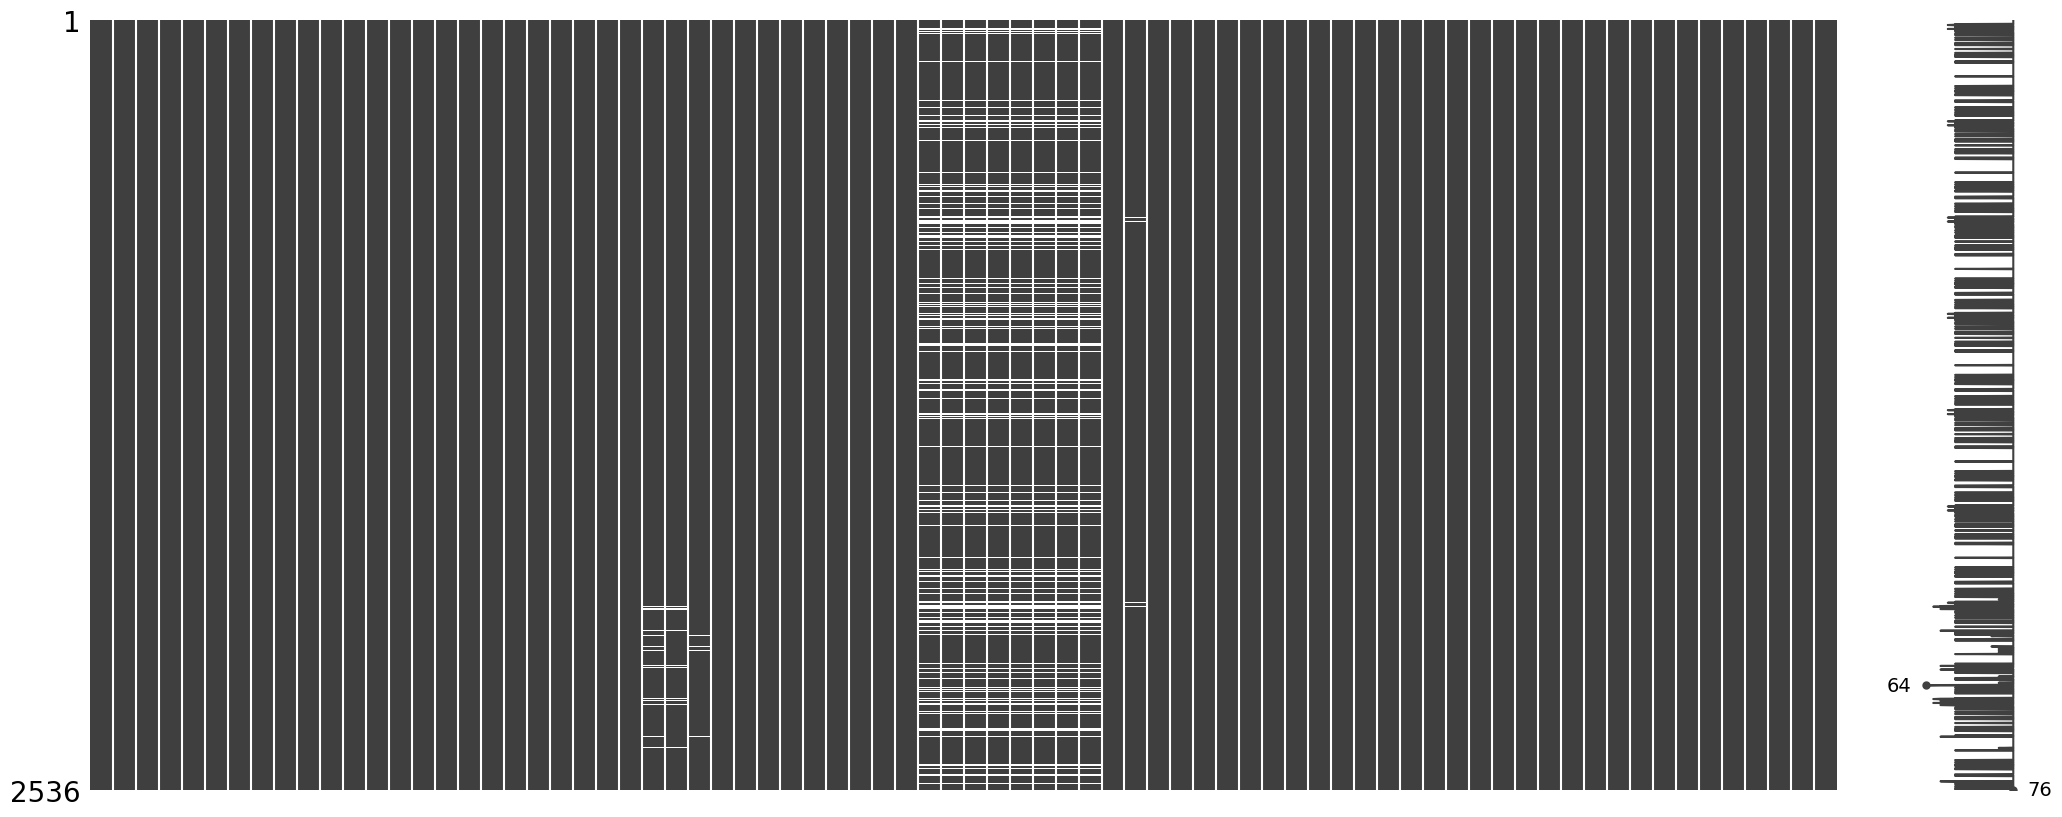

In [388]:
msno.matrix(dataset)

In [389]:
dataset

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.228613,-0.128800,-0.339775,0.128800,0.235684,-0.126217,-0.337048,0.126217,0.024453,0.023984,0.021800,0.023984,25.72,32.47,19.06,0.0055,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,2024,2024-12,29.25,20.33,56.48,355.16,50.0,14.0,36.0,26.67,30.83,34.33,26.50,2007.0,641.0,0.0,139.92,1522.0,0.0,31.0,0.0,15.39,37.66,0.1100
1,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.228112,-0.152122,-0.314715,0.152122,0.226544,-0.148953,-0.316381,0.148953,0.018588,0.017084,0.013574,0.017084,26.29,33.35,19.34,0.0018,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,2024,2024-12,30.21,20.92,59.76,353.85,50.0,15.0,35.0,27.50,31.17,35.33,27.50,2126.0,691.0,0.0,139.58,1609.0,0.0,28.0,1609.0,15.87,38.99,0.4733
2,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.217678,-0.121785,-0.326881,0.121785,0.219530,-0.117612,-0.334587,0.117612,0.017830,0.014757,0.010896,0.014757,25.81,32.30,19.41,0.0132,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,2024,2024-12,29.42,20.83,57.87,363.59,49.0,13.0,36.0,27.17,26.33,34.67,26.33,2132.0,684.0,0.0,139.55,1626.0,0.0,33.0,0.0,16.24,37.34,0.0000
3,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.240727,-0.127691,-0.327832,0.127691,0.245421,-0.126230,-0.330774,0.126230,0.017786,0.014073,0.014566,0.014073,25.21,31.54,18.97,0.0020,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,2024,2024-12,29.00,20.00,57.14,344.44,49.0,14.0,35.0,27.00,30.17,34.17,26.00,2132.0,673.0,0.0,141.63,1634.0,0.0,35.0,0.0,15.76,36.32,0.0000
4,2025-01,2025,1,2024,0.500,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.226639,-0.112302,-0.340948,0.112302,0.227393,-0.115807,-0.333396,0.115807,0.027435,0.024860,0.021228,0.024860,26.04,32.71,19.47,0.0079,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,2024,2024-12,29.62,20.92,56.53,387.37,51.0,14.0,37.0,26.67,31.00,35.33,26.67,2157.0,690.0,0.0,139.21,1627.0,0.0,32.0,1627.0,16.48,37.72,0.4675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2531,2025-08,2025,8,2024,-0.866,-0.500,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,0.605969,0.227675,-0.356192,-0.227675,0.595610,0.223195,-0.355947,-0.223195,0.027736,0.023677,0.023228,0.023677,23.93,26.58,21.29,9.0854,108691.34,1322.49,4.33,172.99,759.46,179.21,0.0,62.92,2224.04,1215.46,3.21,70.29,46.80,2.81,0.0,93.52,31,36.0,30,12,12,3,5,8,2024,2025-07,27.67,20.67,62.63,282.31,47.0,14.0,33.0,26.50,25.33,31.50,25.33,1941.0,597.0,0.0,135.39,1464.0,1.0,61.0,158.0,20.75,33

In [390]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc)